In [20]:
import os
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, matthews_corrcoef, average_precision_score
from pyod.utils.data import precision_n_scores
from pyod.models.iforest import IForest
from sklearn.ensemble import AdaBoostClassifier

In [21]:
!pip -q install lime

import lime
import lime.lime_tabular

In [22]:
def evaluate_metrics(y_test, y_pred, y_proba=None, digits=3):
    res = {"Accuracy": round(accuracy_score(y_test, y_pred), digits),
           "Precision": round(precision_score(y_test, y_pred), digits),
           "Recall": round(recall_score(y_test, y_pred), digits),
           "F1": round(f1_score(y_test, y_pred), digits),
           "MCC": round(matthews_corrcoef(y_test, y_pred), ndigits=digits)}
    if y_proba is not None:
        res["AUC_PR"] = round(average_precision_score(y_test, y_proba), digits)
        res["AUC_ROC"] = round(roc_auc_score(y_test, y_proba), digits)
        res["PREC_N_SCORES"] = round(precision_n_scores(y_test, y_proba), digits)
    return res


def set_seed_numpy(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

In [23]:
features = [
    "mean", "var", "std", "len", "duration", "len_weighted", "gaps_squared", "n_peaks",
    "smooth10_n_peaks", "smooth20_n_peaks", "var_div_duration", "var_div_len",
    "diff_peaks", "diff2_peaks", "diff_var", "diff2_var", "kurtosis", "skew",
]
SEED = 2137

In [24]:
df = pd.read_csv("data/dataset.csv", index_col="segment")

X_train, y_train = df.loc[df.train==1, features], df.loc[df.train==1, "anomaly"]
X_test, y_test = df.loc[df.train==0, features], df.loc[df.train==0, "anomaly"]
X_train_nominal = df.loc[(df.anomaly==0)&(df.train==1), features]

prep = StandardScaler()
X_train_nominal2 = prep.fit_transform(X_train_nominal)
X_train2 = prep.transform(X_train)
X_test2 = prep.transform(X_test)

In [25]:
set_seed_numpy(SEED)

In [26]:
#supervised example 1

In [27]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

#---data->tensors---
Xtr = torch.tensor(np.array(X_train2), dtype=torch.float32)
ytr = torch.tensor(np.array(y_train).reshape(-1, 1), dtype=torch.float32)
Xte = torch.tensor(np.array(X_test2), dtype=torch.float32)
yte = torch.tensor(np.array(y_test).reshape(-1, 1), dtype=torch.float32)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=64, shuffle=True)
text_loader = DataLoader(TensorDataset(Xte, yte), batch_size=256, shuffle=False)

#---model---
class FCNNClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = FCNNClassifier(input_dim=Xtr.shape[1]).to(device)

#---loss & optimizer---
pos = float(ytr.sum().item())
neg = float(len(ytr) - pos)
pos_weight = torch.tensor([neg / max(pos, 1.0)], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

#---training---
def train_epochs(model, epochs=30):
    model.train()
    for ep in range(1, epochs+1):
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(xb)
        if ep % 5 == 0:
            print(f"Epoch {ep:02d} | Loss: {total_loss / len(Xtr):.4f}")
train_epochs(model, epochs=30)

#---evaluation---
model.eval()
with torch.no_grad():
    logits = model(Xte.to(device))
    probs = torch.sigmoid(logits).cpu().numpy()
    y_pred = (probs >= 0.5).astype(int)
print(evaluate_metrics(y_test, y_pred, probs))


Epoch 05 | Loss: 0.5644
Epoch 10 | Loss: 0.4371
Epoch 15 | Loss: 0.3769
Epoch 20 | Loss: 0.3260
Epoch 25 | Loss: 0.3059
Epoch 30 | Loss: 0.2594
{'Accuracy': 0.966, 'Precision': 0.886, 'Recall': 0.965, 'F1': 0.924, 'MCC': 0.903, 'AUC_PR': 0.977, 'AUC_ROC': 0.992, 'PREC_N_SCORES': 0.938}


In [28]:
#LIME
def fcnn_predict_proba(X):
    """X: numpy array of shape (n_samples, n_features) returns: numpy array of shape (n_samples, 2) -> [p_normal, p_anomaly]"""
    model.eval()
    X_t = torch.tensor(np.array(X), dtype=torch.float32).to(device)
    with torch.no_grad():
        logits = model(X_t).cpu().numpy().reshape(-1)
        p_anom = 1 / (1 + np.exp(-logits))
        p_norm = 1 - p_anom
    return np.vstack((p_norm, p_anom)).T

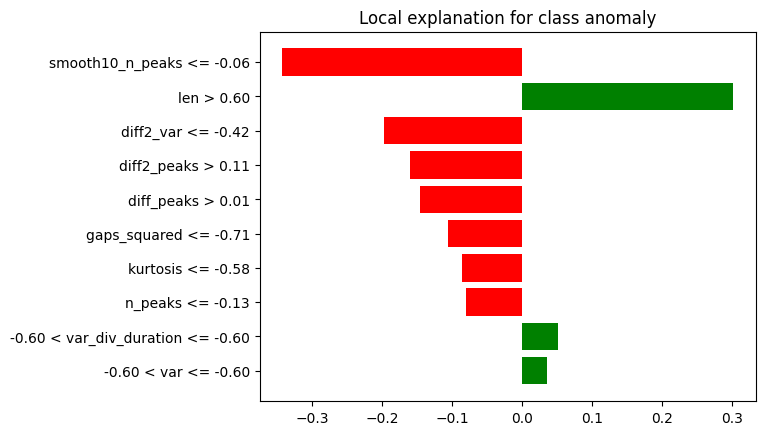

In [29]:
explainer_u = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train2),
    feature_names=features,
    class_names=["normal", "anomaly"],
    mode="classification",
    discretize_continuous=True
)
i = 0 #change to explain different test samples
x = np.array(X_test2[i])
exp = explainer_u.explain_instance(
    data_row=x,
    predict_fn=fcnn_predict_proba,
    num_features=10
)
fig = exp.as_pyplot_figure(label=1)

In [30]:
# supervised example 2

In [31]:
model = AdaBoostClassifier(random_state=SEED)
model.fit(X_train2, y_train)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

AdaBoostClassifier(random_state=2137) 
 {'Accuracy': 0.934, 'Precision': 0.89, 'Recall': 0.788, 'F1': 0.836, 'MCC': 0.797, 'AUC_PR': 0.923, 'AUC_ROC': 0.962, 'PREC_N_SCORES': 0.841}


In [32]:
#LIME explainer (supervised)
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train2),
    feature_names=features,
    class_names=["normal", "anomaly"],
    mode="classification",
    discretize_continuous=True
)
#pick an instance to explain
i = 0 #change this index to explain another instance
x = X_test2[i]
true_label = int(y_test.iloc[i])

#AdaBoost supports predict_proba
exp = explainer.explain_instance(
    data_row=x,
    predict_fn=model.predict_proba,
    num_features=10
)
print("True label:", true_label)
print("Pred probs [normal, anomaly]:", model.predict_proba([x])[0])

print(exp.as_list())




True label: 0
Pred probs [normal, anomaly]: [0.53466724 0.46533276]
[('smooth10_n_peaks <= -0.06', -0.02627424401307427), ('len > 0.60', 0.020813197142465396), ('diff2_peaks > 0.11', -0.018239654884325), ('diff2_var <= -0.42', -0.013630438336830291), ('n_peaks <= -0.13', -0.013114529650975678), ('diff_peaks > 0.01', -0.010685251651539985), ('-0.18 < duration <= 0.47', 0.005890926196393317), ('var_div_len <= -0.53', 0.0046541664456543185), ('-0.60 < var_div_duration <= -0.60', 0.0041298485524939935), ('kurtosis <= -0.58', -0.003879720473622296)]


NameError: name 'plt' is not defined

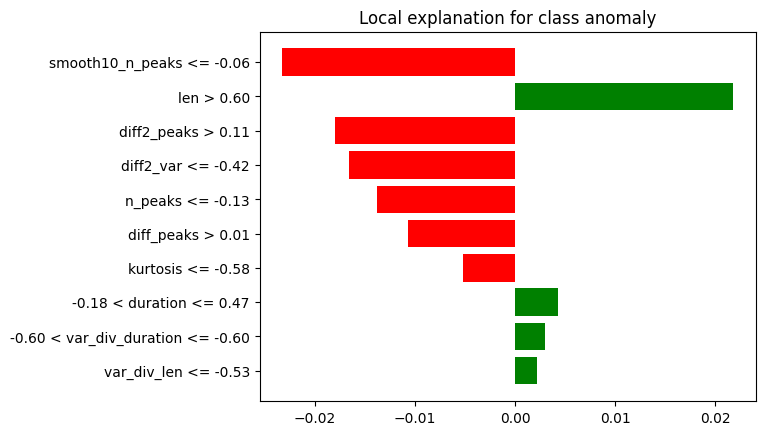

In [33]:
for i in [0, 3, 10, 25]:
    exp_i = explainer.explain_instance(X_test2[i], model.predict_proba, num_features=10)
    exp_i.as_pyplot_figure(label=1)
    plt.title(f"LIME (idx={i}, true label={y_test.iloc[i]})")
    plt.show()

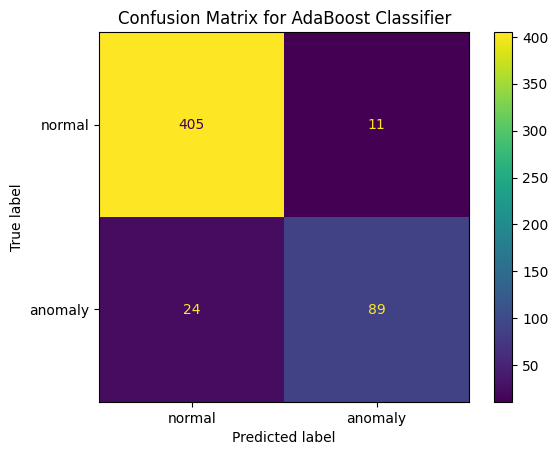

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_predicted, display_labels=["normal", "anomaly"])
plt.title("Confusion Matrix for AdaBoost Classifier")
plt.show()

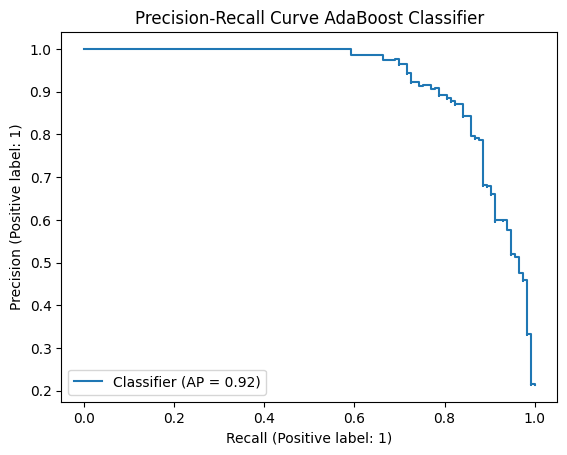

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_predicted_score)
plt.title("Precision-Recall Curve AdaBoost Classifier")
plt.show()

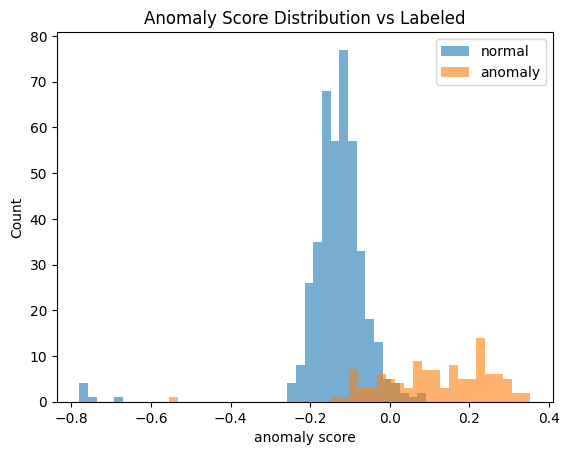

In [ ]:
plt.hist(y_predicted_score[y_test==0], bins=40, alpha=0.6, label="normal")
plt.hist(y_predicted_score[y_test==1], bins=40, alpha=0.6, label="anomaly")
plt.xlabel("anomaly score")
plt.ylabel("Count")
plt.legend()
plt.title("Anomaly Score Distribution vs Labeled")
plt.show()

In [ ]:
# unsupervised example

In [ ]:
model = IForest(random_state=SEED)
model.fit(X_train2)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))

IForest(behaviour='old', bootstrap=False, contamination=0.1, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=2137,
    verbose=0) 
 {'Accuracy': 0.766, 'Precision': 0.4, 'Recall': 0.195, 'F1': 0.262, 'MCC': 0.155, 'AUC_PR': 0.347, 'AUC_ROC': 0.635, 'PREC_N_SCORES': 0.301}


In [ ]:
model = IForest(random_state=SEED, contamination=.2)
model.fit(X_train)

y_predicted = model.predict(X_test2)
y_predicted_score = model.decision_function(X_test2)

print(model, '\n', evaluate_metrics(y_test, y_predicted, y_predicted_score))


IForest(behaviour='old', bootstrap=False, contamination=0.2, max_features=1.0,
    max_samples='auto', n_estimators=100, n_jobs=1, random_state=2137,
    verbose=0) 
 {'Accuracy': 0.544, 'Precision': 0.295, 'Recall': 0.814, 'F1': 0.433, 'MCC': 0.238, 'AUC_PR': 0.237, 'AUC_ROC': 0.574, 'PREC_N_SCORES': 0.071}


In [ ]:
#LIME explainer (unsupervised)
explainer_u = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train2),
    feature_names=features,
    class_names=["normal", "anomaly"],
    mode="classification",
    discretize_continuous=True
)
#sigmoid function to convert scores to pseudo-probabilities
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def iforest_pseudo_proba(X):
    """Returns shape (n_samples, 2): [P(normal), P(anomaly)] We turn the iForest scores into a probability-like number."""
    X = np.array(X)
    
    s = model.decision_function(X)

    z = (s - np.mean(s)) / (np.std(s) + 1e-9)
    p_anom = sigmoid(z) 
    p_norm = 1 - p_anom
    return np.c_[p_norm, p_anom]

i = 0
x = X_test2[i]
true_label = int(y_test.iloc[i])

exp_u = explainer_u.explain_instance(
    data_row=x,
    predict_fn=iforest_pseudo_proba,
    num_features=10
)

print("True label:", true_label)
print("Pseudo probs [normal, anomaly]:", iforest_pseudo_proba([x])[0])

print(exp_u.as_list())


True label: 0
Pseudo probs [normal, anomaly]: [0.5 0.5]
[('smooth10_n_peaks <= -0.06', -0.1436771581002242), ('diff2_var <= -0.42', -0.07968227831912733), ('diff_var <= -0.44', -0.05739240208303839), ('var_div_len <= -0.53', -0.05552502527354966), ('-0.60 < var <= -0.60', -0.04924920145669132), ('-0.60 < var_div_duration <= -0.60', -0.04856305413924434), ('-0.70 < std <= -0.70', -0.04099590504836855), ('-0.60 < mean <= 0.39', -0.03786114600793854), ('kurtosis <= -0.58', -0.036141237173331016), ('-0.62 < skew <= -0.35', -0.020842302392011458)]


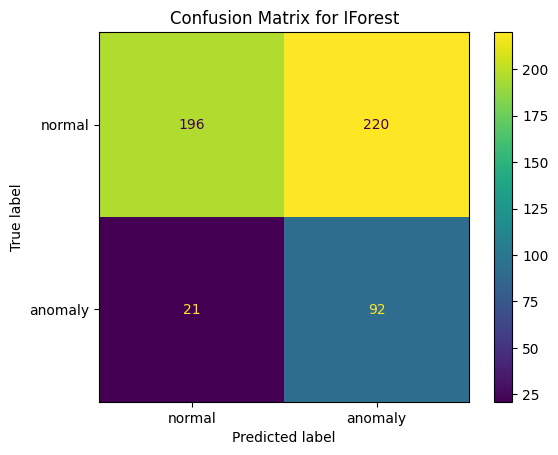

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_predicted, display_labels=["normal", "anomaly"])
plt.title("Confusion Matrix for IForest")
plt.show()


In [ ]:
#shows the distribution of anomaly and normal instances from the labeled set vs what the unsupervised model predicted

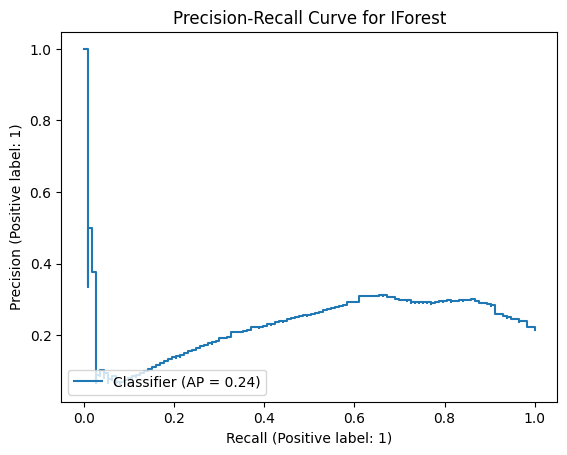

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_predictions(y_test, y_predicted_score)
plt.title("Precision-Recall Curve for IForest")
plt.show()

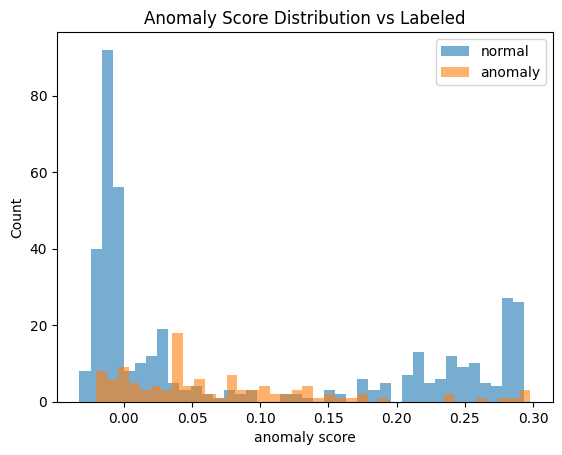

In [ ]:
plt.hist(y_predicted_score[y_test==0], bins=40, alpha=0.6, label="normal")
plt.hist(y_predicted_score[y_test==1], bins=40, alpha=0.6, label="anomaly")
plt.xlabel("anomaly score")
plt.ylabel("Count")
plt.legend()
plt.title("Anomaly Score Distribution vs Labeled")
plt.show()
